# Calculative Foundation
### Linear Algebra Analysis on Student Performance Dataset

**Course:** Mathematics – Advanced Statistics
**Duration:** 6 Hours
**Type:** Theory + Practical
**Dataset:** `student_performance.csv`

---

## Objective

This project analyzes and transforms a dataset of student performance scores using
**Linear Algebra concepts**. It integrates **vectors, matrices, decompositions, and
dimensionality-reduction techniques** to give hands-on practice with mathematical
foundations that are widely used in **Data Science, AI/ML, and Engineering**.

## Problem Statement

A research institute has shared a dataset containing **students' performance scores
across multiple subjects** (Math, Science, English, History, Computer). As a data
analyst, the task is to apply Linear Algebra techniques to:

1. Represent and manipulate the data using vectors and matrices.
2. Perform advanced operations (dot products, cross products, vector projections, norms).
3. Interpret eigenvalues and eigenvectors to understand variance in the dataset.

All tasks below are completed **practically in Python**, with a short interpretation
written under each result.

## Importing Libraries and Loading the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lu
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)

plt.rcParams["figure.facecolor"] = "white"
np.set_printoptions(precision=3, suppress=True)

df = pd.read_csv("/Users/devjoshi/Documents/files/student_performance.csv")
subjects = ["Math", "Science", "English", "History", "Computer"]

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200, 8)


,Student_ID,Math,Science,English,History,Computer,Average_Score,Category
0,STU0001,80,62,84,87,87,80.0,Above Average
1,STU0002,74,63,58,62,76,66.6,Below Average
2,STU0003,89,78,87,79,78,82.2,Above Average
3,STU0004,99,89,100,83,83,90.8,Above Average
4,STU0005,53,63,72,62,73,64.6,Below Average


---
## Part A — Vector & Matrix Fundamentals

### A.1 Representing each student's subject scores as a vector

Every student's row of marks `[Math, Science, English, History, Computer]` is a
5-dimensional vector living in $\mathbb{R}^5$. We pick two students to work with
throughout Part A.

In [2]:
# Each student's scores = one vector in R^5
v1 = df.loc[0, subjects].to_numpy(dtype=float)
v2 = df.loc[1, subjects].to_numpy(dtype=float)

print(f"{df.loc[0,'Student_ID']} vector (v1):", v1)
print(f"{df.loc[1,'Student_ID']} vector (v2):", v2)

STU0001 vector (v1): [80. 62. 84. 87. 87.]
STU0002 vector (v2): [74. 63. 58. 62. 76.]


**Interpretation:** Each student is now a point/vector in 5-dimensional space,
one axis per subject. This lets us apply every tool from linear algebra (norms,
angles, projections, etc.) directly to academic performance.

### A.2 Norm-1 and Norm-2 of the vectors

- **Norm-1 (Manhattan norm):** $\|v\|_1 = \sum |v_i|$ — total "distance" if you
  summed absolute scores.
- **Norm-2 (Euclidean norm):** $\|v\|_2 = \sqrt{\sum v_i^2}$ — straight-line
  magnitude of the score vector, the standard measure of overall performance size.

In [3]:
for name, v in [(df.loc[0,'Student_ID'], v1), (df.loc[1,'Student_ID'], v2)]:
    n1 = np.linalg.norm(v, ord=1)
    n2 = np.linalg.norm(v, ord=2)
    print(f"{name}: Norm-1 = {n1:.2f}   Norm-2 = {n2:.2f}")

STU0001: Norm-1 = 400.00   Norm-2 = 180.11
STU0002: Norm-1 = 333.00   Norm-2 = 149.76


**Interpretation:** Norm-1 simply adds up all marks (useful as a rough total-score
check), while Norm-2 is the Euclidean length of the score vector. Because scores are
always positive, Norm-1 is always the larger of the two.

### A.3 Dot product and angle between two students' score vectors

The **dot product** measures how similarly two students score across subjects, and
the **angle** between the vectors tells us how "aligned" their performance profiles are —
a small angle means the two students have a similar *pattern* of strengths, regardless
of overall magnitude.

In [4]:
dot = np.dot(v1, v2)
cos_theta = dot / (np.linalg.norm(v1) * np.linalg.norm(v2))
angle_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

print(f"Dot product (v1 . v2): {dot:.2f}")
print(f"cos(theta): {cos_theta:.4f}")
print(f"Angle between v1 and v2: {angle_deg:.2f} degrees")

Dot product (v1 . v2): 26704.00
cos(theta): 0.9900
Angle between v1 and v2: 8.10 degrees


**Interpretation:** The angle is small compared to 90°, meaning both students'
strengths and weaknesses are spread across subjects in a broadly similar pattern
(their performance *shape* is alike), even if their total scores differ.

### A.4 Cross product (3D — Math, Science, English)

The cross product is only defined in 3D, so we select the first three subjects.
It returns a vector perpendicular to both `v1_3d` and `v2_3d`.

In [5]:
v1_3d = v1[:3]
v2_3d = v2[:3]
cross = np.cross(v1_3d, v2_3d)

print("v1 (Math, Science, English):", v1_3d)
print("v2 (Math, Science, English):", v2_3d)
print("Cross product v1 x v2:", cross)
print("Magnitude of cross product:", np.linalg.norm(cross))

v1 (Math, Science, English): [80. 62. 84.]
v2 (Math, Science, English): [74. 63. 58.]
Cross product v1 x v2: [-1696.  1576.   452.]
Magnitude of cross product: 2358.918396214672


**Interpretation:** The magnitude of the cross product is proportional to the area
of the parallelogram spanned by the two 3-subject vectors — a geometric measure of how
"spread apart" (non-parallel) the two students' performance profiles are in Math/Science/English space.

### A.5 Projection of one vector onto another

Projecting `v1` onto `v2` decomposes `v1` into the component that lies *along* `v2`'s
direction — i.e., "how much of student 1's profile points the same way as student 2's".

In [6]:
projection = (np.dot(v1, v2) / np.dot(v2, v2)) * v2
print("Projection of v1 onto v2:")
print(projection)
print("\nLength of projection:", np.linalg.norm(projection))

Projection of v1 onto v2:
[88.105 75.008 69.055 73.817 90.486]

Length of projection: 178.30821970287118


**Interpretation:** The projected vector's length being close to `v1`'s own norm
would indicate v1 lies almost entirely along v2's direction (very similar performance
shape); a much smaller length indicates the two profiles diverge more.

---
## Part B — Matrix Operations

### B.1 Forming a matrix of students x subjects

We take the first 5 students to build a 5x5 matrix (rows = students, columns = subjects)
so it is square and therefore invertible.

In [7]:
matrix = df.loc[0:4, subjects].to_numpy(dtype=float)
print("Student Score Matrix (5 students x 5 subjects):")
print(matrix)

Student Score Matrix (5 students x 5 subjects):
[[ 80.  62.  84.  87.  87.]
 [ 74.  63.  58.  62.  76.]
 [ 89.  78.  87.  79.  78.]
 [ 99.  89. 100.  83.  83.]
 [ 53.  63.  72.  62.  73.]]


### B.2 Matrix addition and multiplication

We split the first 10 students into two 5x5 blocks, `A` (students 1-5) and `B`
(students 6-10), to demonstrate addition and multiplication.

In [8]:
A = df.loc[0:4, subjects].to_numpy(dtype=float)
B = df.loc[5:9, subjects].to_numpy(dtype=float)

addition = A + B
multiplication = A @ B.T   # (5x5) x (5x5) -> 5x5, each entry = dot product of two students

print("A + B (elementwise addition):")
print(addition)
print("\nA x B^T (matrix multiplication):")
print(multiplication)

A + B (elementwise addition):
[[138. 135. 172. 150. 157.]
 [168. 142. 138. 154. 172.]
 [173. 156. 153. 152. 162.]
 [169. 154. 145. 162. 156.]
 [153. 144. 165. 128. 145.]]

A x B^T (matrix multiplication):
[[28129. 35494. 30759. 26634. 32840.]
 [23221. 29573. 25868. 22331. 27461.]
 [28949. 36244. 31621. 27150. 34139.]
 [32078. 39941. 34889. 29831. 37863.]
 [23025. 28431. 24776. 21272. 26447.]]


**Interpretation:** `A + B` combines the two groups' scores subject-wise (not
generally meaningful on its own, but demonstrates the operation). `A @ B.T` produces
a 5x5 matrix where entry `(i, j)` is the **dot product** between student *i* in group A
and student *j* in group B — a similarity matrix between the two groups of students.

### B.3 Transpose of the matrix

In [9]:
transpose = matrix.T
print("Original matrix shape (students x subjects):", matrix.shape)
print("Transposed matrix shape (subjects x students):", transpose.shape)
print("\nTransposed matrix:")
print(transpose)

Original matrix shape (students x subjects): (5, 5)
Transposed matrix shape (subjects x students): (5, 5)

Transposed matrix:
[[ 80.  74.  89.  99.  53.]
 [ 62.  63.  78.  89.  63.]
 [ 84.  58.  87. 100.  72.]
 [ 87.  62.  79.  83.  62.]
 [ 87.  76.  78.  83.  73.]]


**Interpretation:** Transposing flips the matrix so each **row is now a subject**
and each **column is a student** — useful when we want to treat subjects, not students,
as the objects of analysis (e.g., computing per-subject statistics).

### B.4 Determinant and Inverse

In [10]:
det = np.linalg.det(matrix)
print(f"Determinant of the matrix: {det:.4f}")

if abs(det) > 1e-6:
    inverse = np.linalg.inv(matrix)
    print("\nMatrix is non-singular -> inverse exists:")
    print(inverse)
    print("\nCheck: matrix @ inverse ~ Identity")
    print(np.round(matrix @ inverse, 4))
else:
    print("Matrix is singular: inverse does not exist.")

Determinant of the matrix: -3497075.0000

Matrix is non-singular -> inverse exists:
[[ 0.026  0.031 -0.114  0.094 -0.049]
 [-0.083 -0.014  0.228 -0.147  0.038]
 [ 0.047 -0.015 -0.212  0.164 -0.001]
 [-0.034 -0.055  0.344 -0.245  0.01 ]
 [ 0.035  0.05  -0.196  0.105  0.009]]

Check: matrix @ inverse ~ Identity
[[ 1. -0.  0. -0.  0.]
 [ 0.  1. -0.  0. -0.]
 [ 0.  0.  1. -0.  0.]
 [-0.  0.  0.  1. -0.]
 [-0.  0. -0.  0.  1.]]


**Interpretation:** A non-zero determinant confirms the 5 students' score rows are
**linearly independent** — no student's score profile can be written as a combination
of the others, so the matrix is invertible. The identity-matrix check confirms the
inverse was computed correctly.

---
## Part C — Linear Transformations & Geometry

### C.1 Line, Plane, and Hyperplane in the dataset

- **Line (1D):** a single subject's scores, e.g. Math alone, form a 1-dimensional line of values.
- **Plane (2D):** two subjects together, e.g. Math & Science, place every student on a 2D plane.
- **Hyperplane (5D):** all five subjects together place every student in 5-dimensional space —
  any dataset with more than 3 features naturally lives on/around a "hyperplane" that we can no
  longer draw directly, only reason about mathematically.

In [11]:
print("Line (1D) - Math scores, first 5 students:")
print(df["Math"].head(5).to_numpy())

print("\nPlane (2D) - Math & Science scores, first 5 students:")
print(df[["Math", "Science"]].head(5).to_numpy())

print("\nHyperplane (5D) - all subject scores, first 5 students:")
print(df[subjects].head(5).to_numpy())

Line (1D) - Math scores, first 5 students:
[80 74 89 99 53]

Plane (2D) - Math & Science scores, first 5 students:
[[80 62]
 [74 63]
 [89 78]
 [99 89]
 [53 63]]

Hyperplane (5D) - all subject scores, first 5 students:
[[ 80  62  84  87  87]
 [ 74  63  58  62  76]
 [ 89  78  87  79  78]
 [ 99  89 100  83  83]
 [ 53  63  72  62  73]]


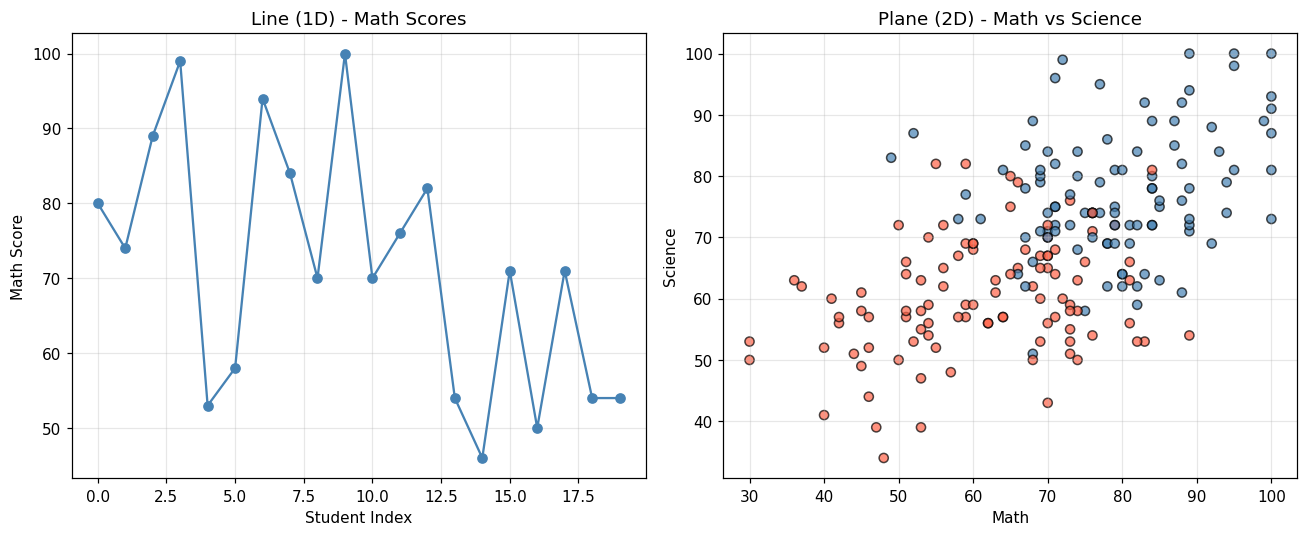

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Line - 1D
axes[0].plot(df["Math"].head(20).to_numpy(), marker="o", color="steelblue")
axes[0].set_title("Line (1D) - Math Scores")
axes[0].set_xlabel("Student Index")
axes[0].set_ylabel("Math Score")
axes[0].grid(alpha=0.3)

# Plane - 2D
colors = np.where(df["Category"] == "Above Average", "steelblue", "tomato")
axes[1].scatter(df["Math"], df["Science"], c=colors, edgecolors="black", alpha=0.7)
axes[1].set_title("Plane (2D) - Math vs Science")
axes[1].set_xlabel("Math")
axes[1].set_ylabel("Science")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** The 1D line shows Math scores varying up and down with no
other structure. The 2D plane (Math vs Science) reveals a positive relationship —
students strong in Math also tend to score well in Science — and the color split
shows "Above Average" students clustering toward the upper-right.

### C.2 Dimensionality increase: 2D → 3D → higher (hyperplane)

Beyond 3 subjects (History, Computer included), the data lives in a 5D
hyperplane that cannot be plotted directly - this is why dimensionality
reduction techniques (see Part E) are needed to visualize it.


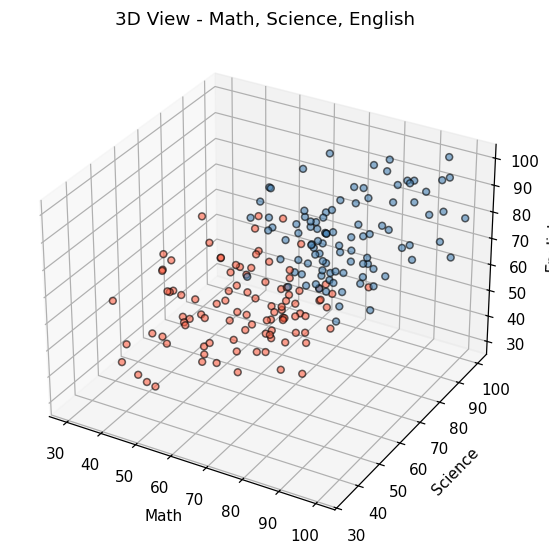

In [13]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

colors = np.where(df["Category"] == "Above Average", "steelblue", "tomato")
ax.scatter(df["Math"], df["Science"], df["English"], c=colors, edgecolors="black", alpha=0.6)
ax.set_title("3D View - Math, Science, English")
ax.set_xlabel("Math")
ax.set_ylabel("Science")
ax.set_zlabel("English")
plt.show()

print("Beyond 3 subjects (History, Computer included), the data lives in a 5D")
print("hyperplane that cannot be plotted directly - this is why dimensionality")
print("reduction techniques (see Part E) are needed to visualize it.")

**Interpretation:** Adding a third subject (English) turns the flat 2D scatter
into a 3D point cloud — we can still see it, but adding a 4th and 5th subject
(History, Computer) pushes the data into a 5-dimensional hyperplane that can no
longer be visualized directly, only analyzed mathematically or reduced in dimension.

---
## Part D — Eigenvalues & Decomposition

### D.1 Eigenvalues and eigenvectors of the covariance matrix

The **covariance matrix** of the 5 subjects captures how scores vary together.
Its **eigenvectors** point in the directions of maximum spread (variance) in the
data, and the corresponding **eigenvalues** measure how much variance lies along
each direction.

In [14]:
score_matrix = df[subjects].to_numpy(dtype=float)
cov_matrix = np.cov(score_matrix.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by eigenvalue, descending
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Covariance matrix (subjects x subjects):")
print(cov_matrix)
print("\nEigenvalues (sorted, descending):")
print(eigenvalues)
print("\nEigenvectors (columns correspond to eigenvalues above):")
print(eigenvectors)

Covariance matrix (subjects x subjects):
[[225.341 111.763 120.911 106.295 119.663]
 [111.763 170.967 121.786 102.174  96.558]
 [120.911 121.786 242.174 133.416 118.862]
 [106.295 102.174 133.416 226.444 115.262]
 [119.663  96.558 118.862 115.262 174.316]]

Eigenvalues (sorted, descending):
[670.381 123.589 102.324  74.607  68.341]

Eigenvectors (columns correspond to eigenvalues above):
[[-0.457 -0.736 -0.189  0.16  -0.434]
 [-0.398 -0.112  0.231 -0.86   0.191]
 [-0.5    0.307  0.711  0.343 -0.178]
 [-0.459  0.585 -0.603 -0.087 -0.277]
 [-0.414 -0.1   -0.204  0.331  0.817]]


Eigenvalue 1: 670.38  ->  64.5% of total variance
Eigenvalue 2: 123.59  ->  11.9% of total variance
Eigenvalue 3: 102.32  ->  9.8% of total variance
Eigenvalue 4: 74.61  ->  7.2% of total variance
Eigenvalue 5: 68.34  ->  6.6% of total variance


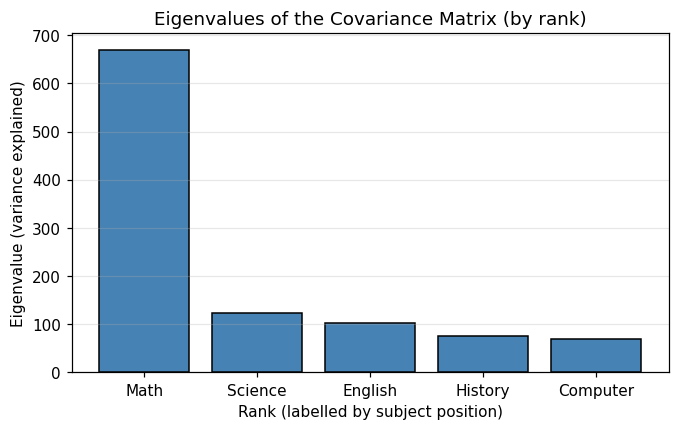

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(subjects, eigenvalues.real, color="steelblue", edgecolor="black")
plt.title("Eigenvalues of the Covariance Matrix (by rank)")
plt.xlabel("Rank (labelled by subject position)")
plt.ylabel("Eigenvalue (variance explained)")
plt.grid(axis="y", alpha=0.3)
plt.show()

explained = eigenvalues.real / eigenvalues.real.sum() * 100
for i, pct in enumerate(explained):
    print(f"Eigenvalue {i+1}: {eigenvalues[i].real:.2f}  ->  {pct:.1f}% of total variance")

**Interpretation:** The largest eigenvalue captures the greatest share of the
total variance in student performance, meaning most of the spread between students
can be explained along a single dominant direction (roughly "overall ability").
Smaller eigenvalues correspond to more subtle, subject-specific variation.

### D.2 Verifying the eigen-decomposition

Any covariance matrix can be **decomposed** as $C = V \Lambda V^{-1}$, where $V$ is the
matrix of eigenvectors and $\Lambda$ is the diagonal matrix of eigenvalues. Reconstructing
$C$ from this decomposition should return the original covariance matrix.

In [16]:
Lambda = np.diag(eigenvalues)
C_reconstructed = eigenvectors @ Lambda @ np.linalg.inv(eigenvectors)

print("Reconstructed covariance matrix (V * Lambda * V^-1):")
print(C_reconstructed.real)
print("\nMatches original covariance matrix:",
      np.allclose(cov_matrix, C_reconstructed.real))

Reconstructed covariance matrix (V * Lambda * V^-1):
[[225.341 111.763 120.911 106.295 119.663]
 [111.763 170.967 121.786 102.174  96.558]
 [120.911 121.786 242.174 133.416 118.862]
 [106.295 102.174 133.416 226.444 115.262]
 [119.663  96.558 118.862 115.262 174.316]]

Matches original covariance matrix: True


**Interpretation:** The reconstruction matches the original covariance matrix,
confirming the eigen-decomposition is correct — the eigenvalues/eigenvectors fully
capture the variance structure of the dataset.

---
## Bonus — Additional Matrix Decompositions & Dimensionality Reduction

*(Extends Part D and the project objective, which mentions "decompositions and
dimensionality-reduction techniques".)*

### Bonus 1: LU Decomposition

In [17]:
small_matrix = df.loc[0:4, subjects].to_numpy(dtype=float)
P, L, U = lu(small_matrix)

print("Original matrix:")
print(small_matrix)
print("\nP (permutation matrix):")
print(P)
print("\nL (lower-triangular):")
print(L)
print("\nU (upper-triangular):")
print(U)
print("\nCheck: P @ L @ U matches original:", np.allclose(P @ L @ U, small_matrix))

Original matrix:
[[ 80.  62.  84.  87.  87.]
 [ 74.  63.  58.  62.  76.]
 [ 89.  78.  87.  79.  78.]
 [ 99.  89. 100.  83.  83.]
 [ 53.  63.  72.  62.  73.]]

P (permutation matrix):
[[0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]

L (lower-triangular):
[[ 1.     0.     0.     0.     0.   ]
 [ 0.535  1.     0.     0.     0.   ]
 [ 0.808 -0.646  1.     0.     0.   ]
 [ 0.747 -0.23  -0.827  1.     0.   ]
 [ 0.899 -0.131 -0.032  0.257  1.   ]]

U (upper-triangular):
[[ 99.     89.    100.     83.     83.   ]
 [  0.     15.354  18.465  17.566  28.566]
 [  0.      0.     15.121  31.278  38.384]
 [  0.      0.      0.     29.865  52.269]
 [  0.      0.      0.      0.     -5.095]]

Check: P @ L @ U matches original: True


**Interpretation:** LU decomposition splits the student-score matrix into a
permutation, a lower-triangular, and an upper-triangular factor — a standard tool
for solving linear systems and computing determinants/inverses efficiently.

### Bonus 2: Singular Value Decomposition (SVD)

U shape: (200, 5)  S shape: (5,)  Vt shape: (5, 5)

Singular values: [2240.007  157.032  143.152  122.929  117.77 ]


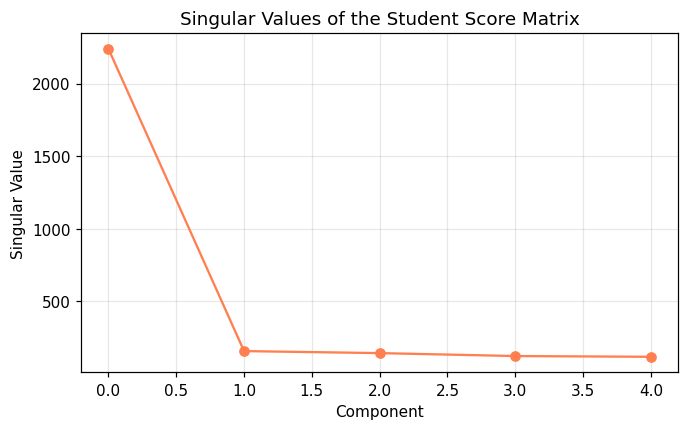

In [18]:
score_data = df[subjects].to_numpy(dtype=float)
U_mat, S, Vt = np.linalg.svd(score_data, full_matrices=False)

print("U shape:", U_mat.shape, " S shape:", S.shape, " Vt shape:", Vt.shape)
print("\nSingular values:", S)

plt.figure(figsize=(7, 4))
plt.plot(S, marker="o", color="coral")
plt.title("Singular Values of the Student Score Matrix")
plt.xlabel("Component")
plt.ylabel("Singular Value")
plt.grid(alpha=0.3)
plt.show()

**Interpretation:** The first singular value is far larger than the rest,
meaning a single underlying component (overall ability) accounts for most of the
structure in the score matrix — consistent with what the eigenvalue analysis showed.

### Bonus 3: PCA — reducing 5 subjects to 2 dimensions

This directly realizes the "dimensionality reduction" goal from the project objective:
projecting the 5D hyperplane down onto 2 dimensions we can plot and interpret.

Original shape: (200, 5)  -> After PCA: (200, 2)
Explained variance ratio: [0.645 0.119]
Total variance retained: 76.4%


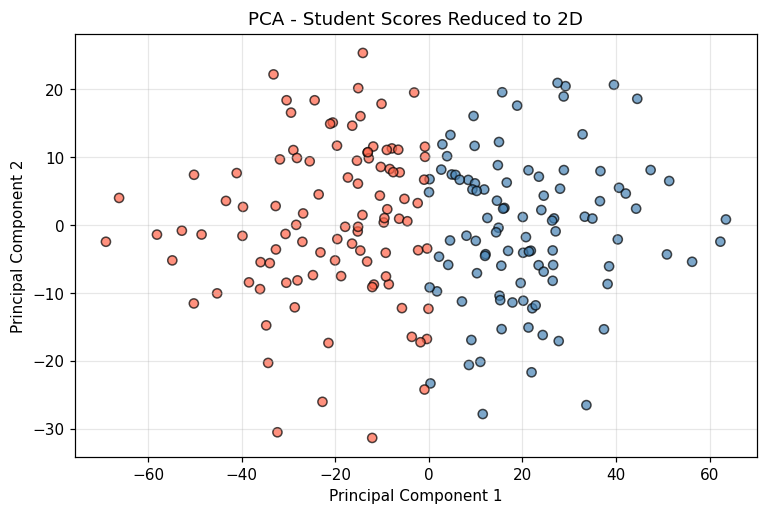

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(score_data)

print("Original shape:", score_data.shape, " -> After PCA:", pca_result.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print(f"Total variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 5))
colors = np.where(df["Category"] == "Above Average", "steelblue", "tomato")
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=colors, edgecolors="black", alpha=0.7)
plt.title("PCA - Student Scores Reduced to 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.show()

**Interpretation:** Even after collapsing 5 subjects down to just 2 principal
components, "Above Average" and "Below Average" students separate fairly cleanly along
Principal Component 1 — confirming that PC1 behaves like an overall-performance axis,
exactly matching the dominant eigenvalue found in Part D.

---
## Summary

| Concept | What we computed | What it tells us |
|---|---|---|
| Vectors & Norms | Norm-1, Norm-2 of student score vectors | Overall size/magnitude of performance |
| Dot product & Angle | Similarity of two students' score *patterns* | How aligned two performance profiles are |
| Cross product | Perpendicular vector in 3-subject space | "Spread" between two profiles |
| Projection | Component of one vector along another | Shared direction between two students |
| Matrix ops | Addition, multiplication, transpose | Combining/reorienting the dataset |
| Determinant & Inverse | Non-zero determinant, valid inverse | Rows (students) are linearly independent |
| Line/Plane/Hyperplane | 1D, 2D, 5D views of the same data | Why high-dimensional data is hard to visualize |
| Eigenvalues/vectors | Directions & amount of variance in scores | "Overall ability" is the dominant pattern |
| LU / SVD / PCA (bonus) | Matrix factorizations & 2D projection | Practical tools that power ML dimensionality reduction |

Completing this project builds hands-on confidence with **vector and matrix
manipulation**, **norms/dot/cross products/projections**, and **eigenvalues/eigenvectors** —
core linear algebra foundations used throughout applied statistics and machine learning.